In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import weibull_min

In [2]:
def get_required_tiles(center_yaw, center_pitch, n=12, fov_yaw=90.0, fov_pitch=90.0):
    """
    Given a center yaw and pitch, compute the required tiles.

    Parameters:
    - center_yaw: Center yaw angle in degrees ([-180, 180]).
    - center_pitch: Center pitch angle in degrees ([-90, 90]).
    - n: Number of tiles per axis (e.g., 8x8 grid).
    - fov_yaw: Field of view in yaw direction in degrees.
    - fov_pitch: Field of view in pitch direction in degrees.

    Returns:
    - A list of (tile_x, tile_y) tuples representing required tiles.
    """
    tile_size_yaw = 360 / n
    tile_size_pitch = 180 / n  # Pitch ranges from -90 to +90

    # Calculate the FOV boundaries
    half_fov_yaw = fov_yaw / 2
    half_fov_pitch = fov_pitch / 2

    # Determine the min and max yaw and pitch
    min_yaw = center_yaw - half_fov_yaw
    max_yaw = center_yaw + half_fov_yaw
    min_pitch = max(center_pitch - half_fov_pitch, -90)
    max_pitch = min(center_pitch + half_fov_pitch, 90)

    required_tiles = set()

    # Calculate tile indices for yaw (handle wrapping in [-180, 180] range)
    yaw_indices = set()
    
    # Convert to [0, 360) range for tile calculation
    def to_normalized_yaw(yaw):
        """Convert yaw from [-180, 180] to [0, 360)"""
        return (yaw + 180) % 360
    
    min_yaw_norm = to_normalized_yaw(min_yaw)
    max_yaw_norm = to_normalized_yaw(max_yaw)
    
    # Handle the case where FOV wraps around the boundary
    if min_yaw_norm <= max_yaw_norm:
        # No wrapping: normal case
        current_yaw = min_yaw_norm
        while current_yaw <= max_yaw_norm:
            tile_idx = int(current_yaw // tile_size_yaw) % n
            yaw_indices.add(tile_idx)
            current_yaw += tile_size_yaw
    else:
        # Wrapping case: goes around ±180°
        # Add tiles from min_yaw_norm to 360
        current_yaw = min_yaw_norm
        while current_yaw < 360:
            tile_idx = int(current_yaw // tile_size_yaw) % n
            yaw_indices.add(tile_idx)
            current_yaw += tile_size_yaw
        
        # Add tiles from 0 to max_yaw_norm
        current_yaw = 0
        while current_yaw <= max_yaw_norm:
            tile_idx = int(current_yaw // tile_size_yaw) % n
            yaw_indices.add(tile_idx)
            current_yaw += tile_size_yaw

    # Calculate tile indices for pitch
    pitch_indices = []
    min_pitch_idx = int((min_pitch + 90) // tile_size_pitch)
    max_pitch_idx = int((max_pitch + 90) // tile_size_pitch)
    for pitch_idx in range(min_pitch_idx, max_pitch_idx + 1):
        if 0 <= pitch_idx < n:
            pitch_indices.append(pitch_idx)

    # Combine yaw and pitch indices to get required tiles
    for yaw_index in yaw_indices:
        for pitch_index in pitch_indices:
            required_tiles.add((yaw_index, pitch_index))

    return list(required_tiles)

In [3]:
def load_and_file(file_path):
    data_df = pd.read_csv(file_path)
    
    return data_df[' cal. yaw'].values, data_df[' cal. pitch'].values

if __name__ == '__main__':
    # global_path = '/home/eduardo/Workspace/CacheVideoPredict360/Dataset/2/coaster_user01_orientation.csv'
    global_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Dataset\2\coaster_user01_orientation.csv'
    yaws, pitches = load_and_file(
        global_path
    )

    # Save values jumping every 30 cells in the same array
    sampled_indices = np.arange(0, len(yaws), 30)
    yaws = yaws[sampled_indices]
    pitches = pitches[sampled_indices]

    print(f"Loaded {len(yaws)} yaw and {len(pitches)} pitch data points.")

def load_all_yaws_pitches(folder_path, step=30):
    """
    Loads all CSV files in the folder and returns arrays of yaws and pitches for each file,
    sampled every `step` rows.

    Returns:
        yaws: np.ndarray of shape (num_files, num_samples)
        pitches: np.ndarray of shape (num_files, num_samples)
    """
    all_yaws = []
    all_pitches = []

    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            yaw_data, pitch_data = load_and_file(file_path)

            sampled_indices = np.arange(0, len(yaw_data), step)
            yaw_data = yaw_data[sampled_indices]
            pitch_data = pitch_data[sampled_indices]

            all_yaws.append(yaw_data)
            all_pitches.append(pitch_data)

    yaws = np.array(all_yaws)
    pitches = np.array(all_pitches)
    return yaws, pitches

Loaded 60 yaw and 60 pitch data points.


In [4]:
def simulate_viewport_with_tiles(
    num_steps,
    n=8,
    fov_yaw=90.0,
    fov_pitch=90.0,
    yaws=None,
    pitches=None,
):
    tiles_per_frame = []

    for step in zip(yaws, pitches):
        current_yaw, current_pitch = step
        
        required_tiles = get_required_tiles(current_yaw, current_pitch, n, fov_yaw, fov_pitch)
        tiles_per_frame.append(set(required_tiles))

    # Convert to 2D array format (for easier processing)
    # Find max number of tiles needed at any frame
    max_tiles = max(len(tiles) for tiles in tiles_per_frame)
    
    # Create 2D array: rows=frames, cols=tile indices
    # Use -1 to indicate unused slots
    tiles_array = np.full((num_steps, max_tiles), -1, dtype=int)

    for frame_idx, tiles_set in enumerate(tiles_per_frame):
        tiles_list = sorted(list(tiles_set))
        for tile_idx, tile in enumerate(tiles_list):
            # Store as linear index: tile_y * n + tile_x
            tiles_array[frame_idx, tile_idx] = tile[1] * n + tile[0]

    return tiles_per_frame, tiles_array


if __name__ == '__main__':
    # global_path = '/home/eduardo/Workspace/CacheVideoPredict360/Dataset/2/coaster_user01_orientation.csv'
    global_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Dataset\2\coaster_user01_orientation.csv'

    yaws, pitches = load_and_file(
        global_path
    )

    # Save values jumping every 30 cells in the same array
    sampled_indices = np.arange(0, len(yaws), 30)
    yaws = yaws[sampled_indices]
    pitches = pitches[sampled_indices]

    # Define parameters for tile calculation
    n_tiles = 4
    fov_yaw_param = 100.0
    fov_pitch_param = 50.0

    tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
        num_steps=len(yaws),
        n=n_tiles,
        fov_yaw=fov_yaw_param,
        fov_pitch=fov_pitch_param,
        yaws=yaws,
        pitches=pitches,
    )

In [5]:
def visualize_trajectory_sequence(
    yaw, 
    pitch, 
    tiles_per_frame, 
    n=8, 
    fov_yaw=90, 
    fov_pitch=90,
    start_frame=0, 
    num_frames_to_show=6, 
    cols=3
):
    """
    Visualizes a sequence of frames from the trajectory showing viewport and required tiles.
    
    Parameters:
    - yaw: Array of yaw positions in degrees ([-180, 180]).
    - pitch: Array of pitch positions in degrees ([-90, 90]).
    - tiles_per_frame: List of sets containing required tiles for each frame.
    - n: Grid size (e.g., 4x4, 8x8).
    - fov_yaw: Field of view in yaw direction in degrees.
    - fov_pitch: Field of view in pitch direction in degrees.
    - start_frame: Which frame to start visualization from.
    - num_frames_to_show: How many frames to display.
    - cols: Number of columns in subplot grid.
    """
    rows = int(np.ceil(num_frames_to_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
    axes = axes.flatten() if num_frames_to_show > 1 else [axes]
    
    for idx in range(num_frames_to_show):
        frame_num = start_frame + idx
        if frame_num >= len(yaw):
            axes[idx].axis('off')
            continue
            
        ax = axes[idx]
        
        # Get viewport parameters for this frame
        center_yaw = yaw[frame_num]
        center_pitch = pitch[frame_num]
        required_tiles = tiles_per_frame[frame_num]
        
        # Create tile grid
        tile_grid = np.zeros((n, n))
        
        # Mark required tiles
        for tile_x, tile_y in required_tiles:
            if 0 <= tile_x < n and 0 <= tile_y < n:
                tile_grid[tile_y, tile_x] = 1
        
        # Display the grid (yaw: -180 to 180, pitch: -90 to 90)
        ax.imshow(
            tile_grid,  
            interpolation='nearest', 
            origin='lower',
            cmap='RdYlGn',
            extent=[-180, 180, -90, 90], 
            aspect='auto', 
            vmin=0, 
            vmax=1
        )
        
        # Draw grid lines
        tile_size_yaw = 360 / n
        tile_size_pitch = 180 / n
        
        # Yaw grid lines (from -180 to 180)
        for i in range(n + 1):
            yaw_line = -180 + i * tile_size_yaw
            ax.axvline(yaw_line, color='gray', linewidth=0.3, alpha=0.5)
        
        # Pitch grid lines (from -90 to 90)
        for i in range(n + 1):
            pitch_line = -90 + i * tile_size_pitch
            ax.axhline(pitch_line, color='gray', linewidth=0.3, alpha=0.5)
        
        # Draw viewport FOV rectangle
        half_fov_yaw = fov_yaw / 2
        half_fov_pitch = fov_pitch / 2
        
        min_yaw = center_yaw - half_fov_yaw
        max_yaw = center_yaw + half_fov_yaw
        min_pitch = max(center_pitch - half_fov_pitch, -90)
        max_pitch = min(center_pitch + half_fov_pitch, 90)
        
        # Handle yaw wrapping in [-180, 180] range
        if min_yaw >= -180 and max_yaw <= 180:
            # No wrapping needed
            ax.add_patch(plt.Rectangle(
                (min_yaw, min_pitch), 
                fov_yaw, 
                max_pitch - min_pitch,
                fill=False, 
                edgecolor='blue', 
                linewidth=1.5
            ))
        else:
            # Wrapping occurs
            if min_yaw < -180:
                # Left side wraps to right
                ax.add_patch(plt.Rectangle(
                    (min_yaw + 360, min_pitch), 
                    180 - (min_yaw + 360), 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
                ax.add_patch(plt.Rectangle(
                    (-180, min_pitch), 
                    max_yaw + 180, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
            elif max_yaw > 180:
                # Right side wraps to left
                ax.add_patch(plt.Rectangle(
                    (min_yaw, min_pitch), 
                    180 - min_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
                ax.add_patch(plt.Rectangle(
                    (-180, min_pitch), 
                    max_yaw - 180, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
        
        # Mark center
        ax.plot(center_yaw, center_pitch, 'r*', markersize=8)
        
        # Set labels and limits
        ax.set_xlim(-180, 180)
        ax.set_ylim(-90, 90)
        ax.set_title(f'Frame {frame_num}\n({center_yaw:.1f}°, {center_pitch:.1f}°)\n{len(required_tiles)} tiles',
                     fontsize=9)
        ax.set_xlabel('Yaw (degrees)', fontsize=8)
        ax.set_ylabel('Pitch (degrees)', fontsize=8)
        ax.tick_params(labelsize=7)
    
    # Hide any unused subplots
    for idx in range(num_frames_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Viewport Trajectory Visualization (Frames {start_frame}-{start_frame+num_frames_to_show-1})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

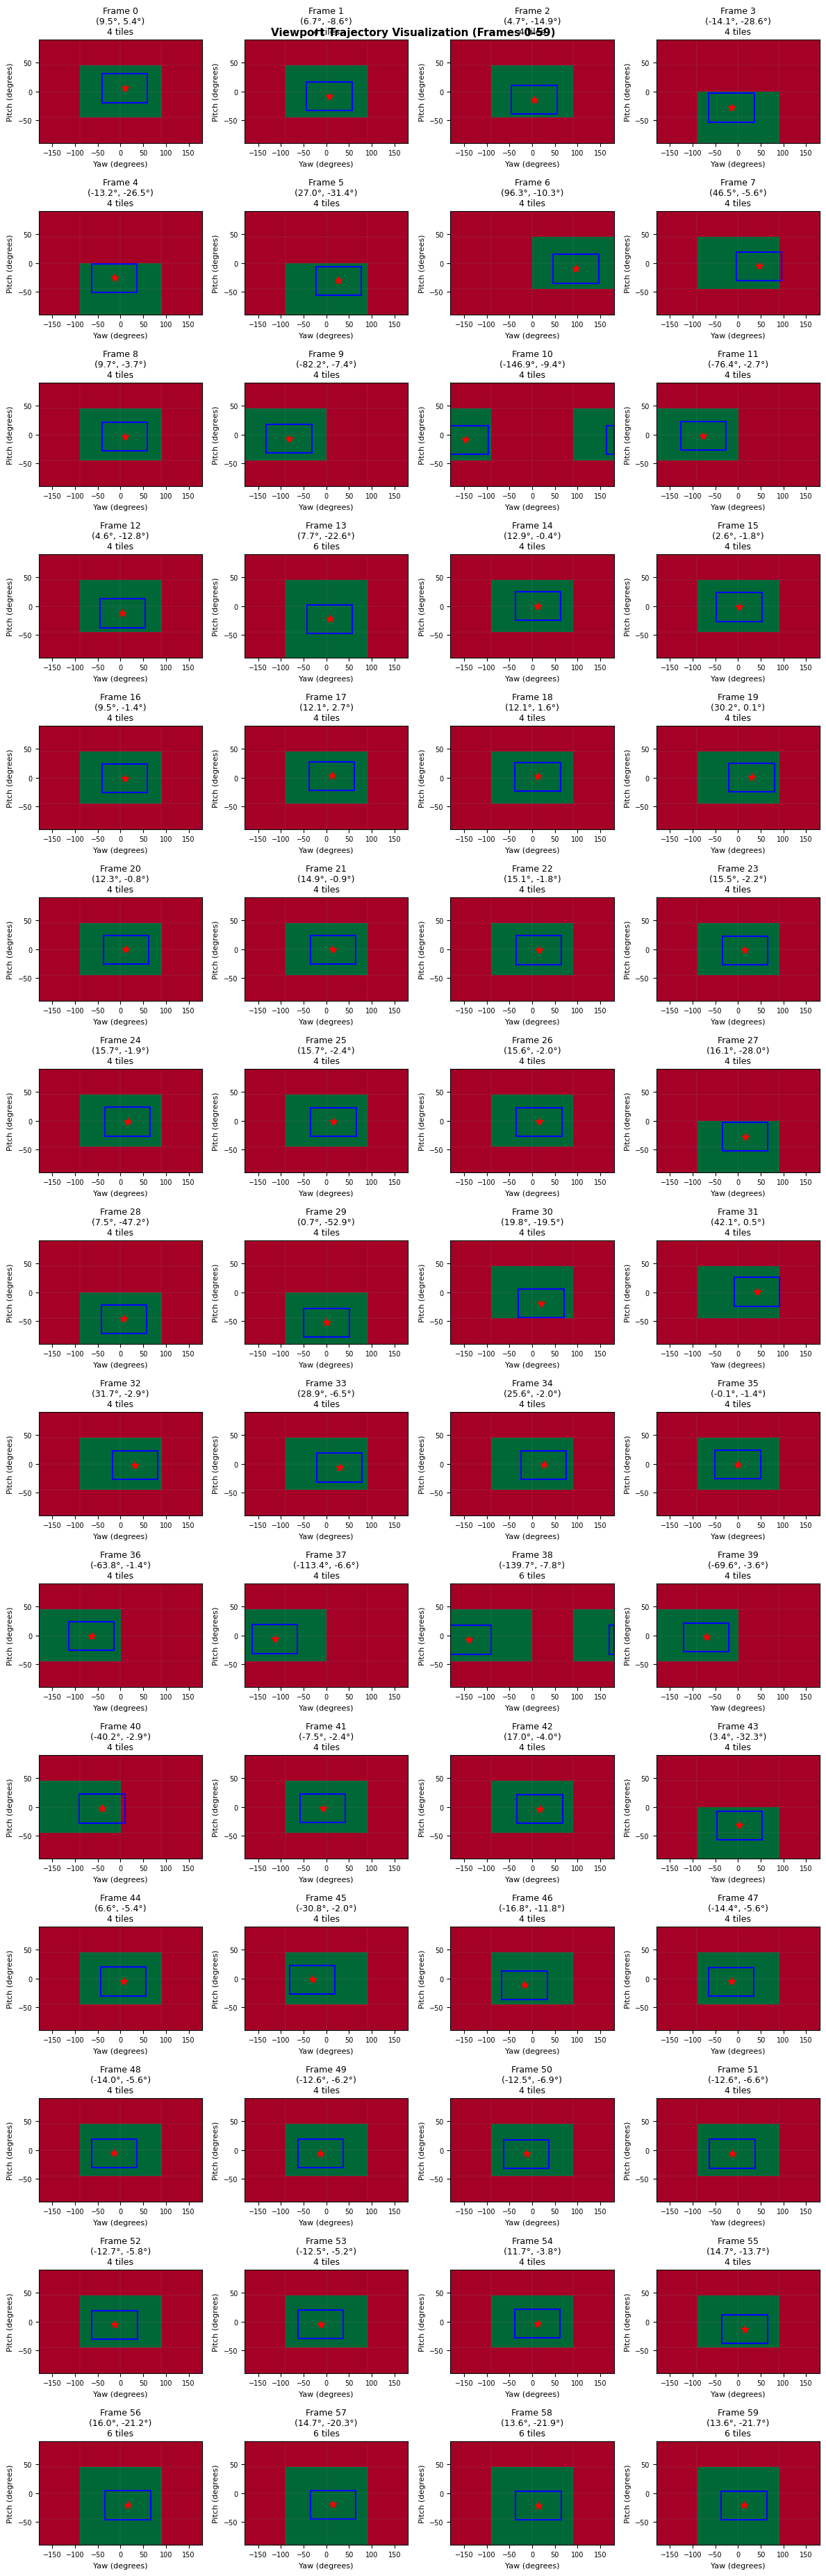

In [6]:
if __name__ == '__main__':
    idx = 254  # Index of the trajectory to visualize
    n_tiles = 4
    fov_yaw_param = 100.0
    fov_pitch_param = 50.0

    # Usage:
    yaws, pitches = load_all_yaws_pitches(
        r'c:\Users\es25591\Workspace\CacheVideoPredict360\Dataset\2'
        # '/home/eduardo/Workspace/CacheVideoPredict360/Dataset/2'
    )

    yaws = np.array(yaws)
    pitches = np.array(pitches)

    tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
        num_steps=len(yaws[idx]),
        n=n_tiles,
        fov_yaw=fov_yaw_param,
        fov_pitch=fov_pitch_param,
        yaws=yaws[idx],
        pitches=pitches[idx],
    )

    # Visualize a sequence of 12 frames in a 4x3 grid
    visualize_trajectory_sequence(
        yaw=yaws[idx],
        pitch=pitches[idx],
        tiles_per_frame=tiles_per_frame,
        n=n_tiles,
        fov_yaw=fov_yaw_param,
        fov_pitch=fov_pitch_param,
        start_frame=0,
        num_frames_to_show=60,
        cols=4
    )